# Matrix Inverse

Notebook ini merangkum Chapter 8 dari *Practical Linear Algebra for Data Science*. Chapter ini membahas **matrix inverse**, yaitu konsep penting untuk menyelesaikan matrix equation seperti $Ax=b$.

Pembahasan dibuat ringkas seperti Chapter 3: fokus pada isi chapter, rumus yang relevan, kode inti, dan kesimpulan.

## Tujuan Pembelajaran

- Memahami definisi matrix inverse.
- Menjelaskan peran inverse dalam menyelesaikan persamaan $Ax=b$.
- Membedakan full inverse, one-sided inverse, dan pseudoinverse.
- Mengetahui syarat matrix agar memiliki inverse.
- Menghitung inverse matrix $2 \times 2$ dan diagonal matrix.
- Memahami left-inverse untuk tall matrix.
- Memahami konsep uniqueness dari inverse.
- Menggunakan Moore-Penrose pseudoinverse.
- Memahami risiko numerical instability pada inverse.
- Menjelaskan interpretasi geometri dari matrix inverse.

## Ringkasan Chapter

Chapter ini memperkenalkan matrix inverse sebagai matrix yang dapat “membatalkan” efek matrix lain melalui matrix multiplication. Jika $A^{-1}$ adalah inverse dari $A$, maka perkalian keduanya menghasilkan identity matrix.

Inverse penting karena digunakan untuk menyelesaikan matrix equation seperti $Ax=b$. Secara konsep, inverse memungkinkan matrix $A$ dipindahkan atau dibatalkan sehingga solusi $x$ dapat ditemukan. Namun, tidak semua matrix memiliki inverse.

Chapter ini membahas tiga jenis inverse: full inverse, one-sided inverse, dan pseudoinverse. Full inverse hanya dimiliki oleh square full-rank matrix. One-sided inverse dimiliki oleh rectangular matrix tertentu yang memiliki maximum possible rank. Pseudoinverse tersedia untuk semua matrix, termasuk reduced-rank matrix.

Chapter ini juga menjelaskan cara menghitung inverse untuk matrix khusus seperti matrix $2 \times 2$ dan diagonal matrix, serta membahas left-inverse, uniqueness dari inverse, Moore-Penrose pseudoinverse, numerical stability, Hilbert matrix, dan interpretasi geometri bahwa inverse dapat membalikkan transformasi matrix.

## Struktur Pembahasan Chapter

| Bagian | Inti Pembahasan |
|---|---|
| The Matrix Inverse | Inverse adalah matrix yang menghasilkan identity matrix saat dikalikan dengan matrix asal. |
| Types of Inverses | Full inverse, one-sided inverse, dan pseudoinverse memiliki syarat berbeda. |
| Computing the Inverse | Inverse tidak diperoleh dengan membalik setiap elemen matrix. |
| Inverse of Special Matrices | Matrix $2 \times 2$ dan diagonal matrix memiliki shortcut inverse. |
| One-Sided Inverses | Tall matrix dapat memiliki left-inverse, wide matrix dapat memiliki right-inverse. |
| Uniqueness | Full inverse bersifat unik. |
| Moore-Penrose Pseudoinverse | Pseudoinverse dapat dihitung untuk semua matrix. |
| Numerical Stability | Inverse dapat tidak stabil secara numerik, terutama pada Hilbert matrix. |
| Geometric Interpretation | Inverse membalikkan geometric transformation. |

## Persiapan Library

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

try:
    import scipy.linalg
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

np.random.seed(2024)

## The Matrix Inverse

Inverse dari matrix $A$ adalah matrix lain yang ditulis sebagai $A^{-1}$. Matrix ini jika dikalikan dengan $A$ akan menghasilkan identity matrix.

### Rumus Matrix Inverse

$$
A^{-1}A = I
$$

atau untuk full inverse:

$$
A^{-1}A = AA^{-1} = I
$$

Keterangan:

- $A$ = matrix asal
- $A^{-1}$ = inverse dari matrix $A$
- $I$ = identity matrix

Inverse dapat dipahami sebagai transformasi linear yang mengubah matrix asal menjadi identity matrix.

## Inverse untuk Menyelesaikan Matrix Equation

Matrix inverse penting karena dapat digunakan untuk menyelesaikan persamaan:

$$
Ax=b
$$

Jika $A$ memiliki inverse, maka:

$$
A^{-1}Ax = A^{-1}b
$$

$$
Ix = A^{-1}b
$$

$$
x = A^{-1}b
$$

Keterangan:

- $A$ dan $b$ diketahui
- $x$ adalah variable yang dicari
- $A^{-1}$ digunakan untuk membatalkan matrix $A$

Walaupun bentuknya terlihat sederhana, chapter menekankan bahwa menghitung inverse tidak selalu mudah dan tidak selalu mungkin.

In [2]:
A = np.array([
    [2, 1],
    [1, 3]
])

b = np.array([5, 7])

x = np.linalg.inv(A) @ b

print("Solution x:", x)
print("Check A @ x:", A @ x)

Solution x: [1.6 1.8]
Check A @ x: [5. 7.]


## Types of Inverses and Conditions for Invertibility

Chapter ini membedakan tiga jenis inverse.

| Jenis Inverse | Syarat | Ciri Utama |
|---|---|---|
| Full inverse | Square dan full-rank | Berlaku dua sisi: $A^{-1}A=AA^{-1}=I$ |
| One-sided inverse | Rectangular dan maximum possible rank | Hanya berlaku dari satu sisi |
| Pseudoinverse | Semua matrix | Selalu ada, termasuk untuk reduced-rank matrix |

Matrix yang tidak memiliki full atau one-sided inverse disebut **singular**, **noninvertible**, **reduced-rank**, atau **rank-deficient**.

## Full Inverse

Full inverse hanya dimiliki matrix yang memenuhi dua syarat:

1. Matrix harus square.
2. Matrix harus full-rank.

Jika dua syarat ini terpenuhi, matrix memiliki inverse penuh sehingga:

$$
A^{-1}A = AA^{-1} = I
$$

Setiap square full-rank matrix memiliki inverse, dan setiap matrix yang memiliki full inverse pasti square dan full-rank.

## One-Sided Inverse

Rectangular matrix tidak memiliki full inverse, tetapi dapat memiliki one-sided inverse.

Untuk tall matrix $T$, left-inverse $L$ memenuhi:

$$
LT = I
$$

tetapi biasanya:

$$
TL \ne I
$$

Untuk wide matrix $W$, right-inverse $R$ memenuhi:

$$
WR = I
$$

tetapi biasanya:

$$
RW \ne I
$$

One-sided inverse hanya ada jika rectangular matrix memiliki maximum possible rank.

## Pseudoinverse

Pseudoinverse dimiliki oleh semua matrix, apa pun shape dan rank-nya. Jika matrix square full-rank, pseudoinverse sama dengan full inverse. Jika matrix rectangular dan maximum-rank, pseudoinverse sama dengan one-sided inverse.

Untuk reduced-rank matrix, pseudoinverse tidak menghasilkan identity matrix secara sempurna, tetapi menghasilkan matrix yang mendekati identity matrix.

## Computing the Inverse

Chapter menekankan bahwa inverse matrix tidak sama dengan membalik setiap elemen matrix.

Misalnya:

$$
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix}^{-1}
\ne
\begin{bmatrix}
1/a & 1/b \\
1/c & 1/d
\end{bmatrix}
$$

Jika elemen-elemen matrix dibalik satu per satu, hasil perkaliannya tidak menghasilkan identity matrix. Karena itu, matrix inverse membutuhkan algoritma khusus.

In [3]:
A = np.array([
    [1, 4],
    [2, 7]
], dtype=float)

elementwise_inverse = 1 / A
true_inverse = np.linalg.inv(A)

print("Element-wise inverse:")
print(elementwise_inverse)

print("\nTrue matrix inverse:")
print(true_inverse)

print("\nA @ element-wise inverse:")
print(A @ elementwise_inverse)

print("\nA @ true inverse:")
print(A @ true_inverse)

Element-wise inverse:
[[1.         0.25      ]
 [0.5        0.14285714]]

True matrix inverse:
[[-7.  4.]
 [ 2. -1.]]

A @ element-wise inverse:
[[3.         0.82142857]
 [5.5        1.5       ]]

A @ true inverse:
[[1. 0.]
 [0. 1.]]


## Inverse of a 2 × 2 Matrix

Untuk matrix $2 \times 2$, inverse dapat dihitung dengan shortcut tertentu.

### Rumus Inverse Matrix 2 × 2

Jika:

$$
A =
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix}
$$

maka:

$$
A^{-1}
=
\frac{1}{ad-bc}
\begin{bmatrix}
d & -b \\
-c & a
\end{bmatrix}
$$

Keterangan:

- $ad-bc$ = determinant matrix $A$
- Jika $ad-bc=0$, matrix tidak memiliki inverse
- Diagonal elements ditukar
- Off-diagonal elements dikalikan dengan $-1$

In [4]:
A = np.array([
    [1, 4],
    [2, 7]
])

Ainv = np.linalg.inv(A)

print("A:")
print(A)

print("\nA inverse:")
print(Ainv)

print("\nA @ Ainv:")
print(A @ Ainv)

print("\nAinv @ A:")
print(Ainv @ A)

A:
[[1 4]
 [2 7]]

A inverse:
[[-7.  4.]
 [ 2. -1.]]

A @ Ainv:
[[1. 0.]
 [0. 1.]]

Ainv @ A:
[[1. 0.]
 [0. 1.]]


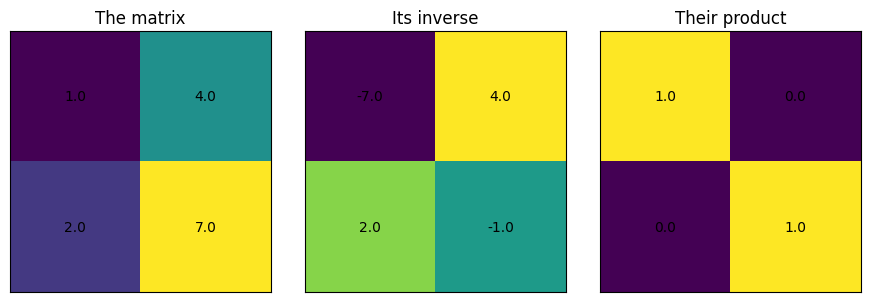

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

items = [
    ("The matrix", A),
    ("Its inverse", Ainv),
    ("Their product", A @ Ainv)
]

for ax, (title, mat) in zip(axes, items):
    ax.imshow(mat)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat[i,j]:.1f}", ha="center", va="center")

plt.tight_layout()
plt.show()

## Reduced-Rank Matrix Tidak Memiliki Inverse

Jika determinant matrix $2 \times 2$ bernilai nol, maka inverse tidak bisa dihitung karena rumus inverse membutuhkan pembagian dengan determinant.

Contoh matrix:

$$
A =
\begin{bmatrix}
1 & 4 \\
2 & 8
\end{bmatrix}
$$

Matrix ini reduced-rank karena row kedua merupakan kelipatan row pertama. Determinant-nya nol, sehingga matrix tidak invertible.

In [6]:
A_singular = np.array([
    [1, 4],
    [2, 8]
])

print("Rank:", np.linalg.matrix_rank(A_singular))
print("Determinant:", np.linalg.det(A_singular))

try:
    np.linalg.inv(A_singular)
except np.linalg.LinAlgError as e:
    print("Error:", e)

Rank: 1
Determinant: 0.0
Error: Singular matrix


## Inverse of a Diagonal Matrix

Diagonal matrix memiliki shortcut inverse. Jika semua diagonal elements nonzero, inverse diagonal matrix diperoleh dengan membalik elemen diagonalnya.

Contoh:

$$
D =
\begin{bmatrix}
2 & 0 & 0 \\
0 & 3 & 0 \\
0 & 0 & 4
\end{bmatrix}
$$

maka:

$$
D^{-1} =
\begin{bmatrix}
1/2 & 0 & 0 \\
0 & 1/3 & 0 \\
0 & 0 & 1/4
\end{bmatrix}
$$

Jika terdapat nol pada diagonal, diagonal matrix tidak memiliki inverse.

In [7]:
D = np.diag([2, 3, 4])
Dinv = np.linalg.inv(D)

print("D:")
print(D)

print("\nD inverse:")
print(Dinv)

print("\nD @ Dinv:")
print(D @ Dinv)

D:
[[2 0 0]
 [0 3 0]
 [0 0 4]]

D inverse:
[[0.5        0.         0.        ]
 [0.         0.33333333 0.        ]
 [0.         0.         0.25      ]]

D @ Dinv:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


## Inverting Any Square Full-Rank Matrix

Untuk square full-rank matrix umum, chapter menjelaskan algoritma inverse menggunakan beberapa matrix antara:

| Matrix | Penjelasan |
|---|---|
| Minors matrix | Berisi determinant dari submatrix setelah row dan column tertentu dihapus. |
| Grid matrix | Checkerboard berisi $+1$ dan $-1$. |
| Cofactors matrix | Hadamard multiplication antara minors matrix dan grid matrix. |
| Adjugate matrix | Transpose dari cofactors matrix, lalu diskalakan dengan inverse determinant. |

Adjugate matrix itulah inverse dari matrix asal.

## Rumus Grid Matrix

Grid matrix menggunakan pola tanda bergantian:

$$
g_{i,j}=(-1)^{i+j}
$$

Keterangan:

- $g_{i,j}$ = elemen grid matrix pada posisi row ke-$i$ dan column ke-$j$
- Pola dimulai dengan $+1$ di kiri atas
- Indeks matematika dimulai dari 1, sedangkan Python dimulai dari 0 sehingga implementasi perlu hati-hati

In [8]:
n = 4
grid = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        grid[i, j] = (-1) ** (i + j)

print(grid)

[[ 1. -1.  1. -1.]
 [-1.  1. -1.  1.]
 [ 1. -1.  1. -1.]
 [-1.  1. -1.  1.]]


## One-Sided Inverses

Tall matrix tidak memiliki full inverse karena bentuknya tidak square. Namun, tall full column-rank matrix dapat memiliki left-inverse.

Tujuannya adalah mencari matrix $L$ sehingga:

$$
LT = I
$$

Chapter menurunkan left-inverse dengan membuat matrix tall menjadi square melalui $T^TT$.

## Rumus Left-Inverse

Untuk tall matrix $T$, left-inverse dihitung sebagai:

$$
L = (T^TT)^{-1}T^T
$$

Sehingga:

$$
LT = I
$$

Keterangan:

- $T$ = tall matrix dengan full column-rank
- $L$ = left-inverse
- $T^TT$ = square full-rank matrix jika $T$ full column-rank

Namun, biasanya:

$$
TL \ne I
$$

Karena itu disebut one-sided inverse.

In [9]:
T = np.random.randint(-10, 11, size=(40, 4))

TtT = T.T @ T
TtT_inv = np.linalg.inv(TtT)

L = TtT_inv @ T.T

print("T shape:", T.shape)
print("L shape:", L.shape)

print("\nL @ T:")
print(np.round(L @ T, 6))

print("\nT @ L shape:", (T @ L).shape)

T shape: (40, 4)
L shape: (4, 40)

L @ T:
[[ 1. -0.  0.  0.]
 [-0.  1. -0.  0.]
 [-0. -0.  1. -0.]
 [-0.  0.  0.  1.]]

T @ L shape: (40, 40)


## The Inverse Is Unique

Full inverse bersifat unik. Artinya, jika matrix $A$ memiliki inverse, hanya ada satu matrix yang dapat menjadi inverse-nya.

Chapter memberikan proof by negation. Misalkan $B$ dan $C$ sama-sama inverse dari $A$, maka:

$$
C = CI = CAB = IB = B
$$

Keterangan:

- $AB=I$ karena $B$ inverse dari $A$
- $CA=I$ karena $C$ inverse dari $A$
- Hasil akhirnya menunjukkan $C=B$

Jadi, asumsi bahwa ada dua inverse berbeda adalah salah.

## Moore-Penrose Pseudoinverse

Reduced-rank matrix tidak memiliki full inverse atau one-sided inverse. Namun, reduced-rank matrix tetap memiliki pseudoinverse.

Pseudoinverse yang paling umum digunakan adalah **Moore-Penrose pseudoinverse**, biasanya ditulis sebagai:

$$
A^\dagger
$$

atau:

$$
A^+
$$

Di Python, pseudoinverse dihitung menggunakan:

```python
np.linalg.pinv(A)
```

In [10]:
A = np.array([
    [1, 4],
    [2, 8]
])

Apinv = np.linalg.pinv(A)

print("A pseudoinverse:")
print(Apinv)

print("\nA @ Apinv:")
print(A @ Apinv)

A pseudoinverse:
[[0.01176471 0.02352941]
 [0.04705882 0.09411765]]

A @ Apinv:
[[0.2 0.4]
 [0.4 0.8]]


## Pseudoinverse dan SVD

Chapter menjelaskan secara singkat bahwa Moore-Penrose pseudoinverse dapat dihitung melalui singular value decomposition.

Secara konsep:

1. Ambil SVD dari matrix.
2. Balik singular values yang nonzero.
3. Biarkan singular vectors tetap.
4. Rekonstruksi matrix menggunakan komponen SVD.

Detail konsep ini belum dijelaskan penuh pada chapter ini karena SVD baru akan dibahas lebih lanjut di Chapter 13.

## Numerical Stability of the Inverse

Menghitung inverse membutuhkan banyak floating-point operations. Karena itu, inverse dapat mengalami masalah numerical stability, terutama pada matrix yang memiliki rentang nilai sangat besar.

Chapter menyebut bahwa library numerical computation sering berusaha menghindari explicit inverse jika memungkinkan. Alternatifnya, matrix dapat didekomposisi menjadi bentuk lain yang lebih stabil, seperti QR decomposition.

## Hilbert Matrix

Hilbert matrix adalah contoh matrix yang secara numerik tidak stabil. Setiap elemennya didefinisikan sebagai:

$$
h_{i,j} =
\frac{1}{i+j-1}
$$

Keterangan:

- $h_{i,j}$ = elemen Hilbert matrix pada row ke-$i$ dan column ke-$j$
- $i$ dan $j$ = indeks row dan column
- Semakin besar ukuran Hilbert matrix, semakin tinggi risiko numerical instability

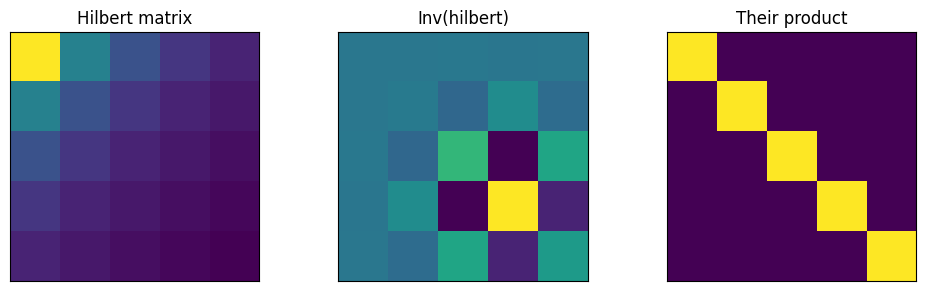

Condition number: 476607.2502422687


In [11]:
def hilbert_matrix(n):
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            H[i, j] = 1 / (i + j + 1)
    return H

H = hilbert_matrix(5)
Hinv = np.linalg.inv(H)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))

items = [
    ("Hilbert matrix", H),
    ("Inv(hilbert)", Hinv),
    ("Their product", H @ Hinv)
]

for ax, (title, mat) in zip(axes, items):
    ax.imshow(mat)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

print("Condition number:", np.linalg.cond(H))

## Geometric Interpretation of the Inverse

Chapter juga memberikan interpretasi geometri: matrix inverse membalikkan transformasi yang dilakukan oleh matrix multiplication.

Jika:

$$
Q = TP
$$

dan:

$$
U = T^{-1}Q
$$

maka:

$$
U = T^{-1}TP
$$

Sehingga:

$$
U = P
$$

Keterangan:

- $P$ = koordinat awal
- $T$ = transformation matrix
- $Q$ = koordinat setelah transformasi
- $U$ = koordinat setelah inverse-transform

Jika matrix singular membuat satu dimensi menjadi “flattened”, transformasi tersebut tidak dapat dibalik sempurna. Inilah intuisi mengapa reduced-rank matrix tidak memiliki inverse.

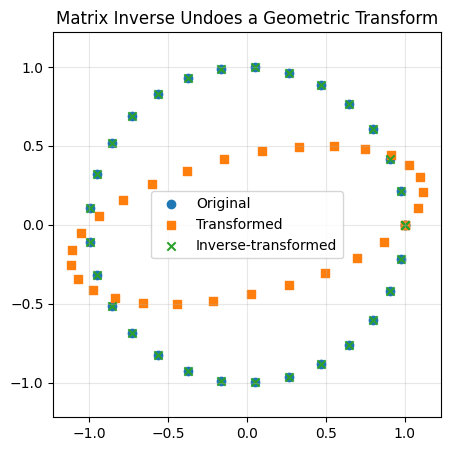

In [12]:
theta = np.linspace(0, 2*np.pi, 30)
P = np.vstack((np.cos(theta), np.sin(theta)))

T = np.array([
    [1, .5],
    [0, .5]
])

Q = T @ P
U = np.linalg.inv(T) @ Q

plt.figure(figsize=(5, 5))
plt.scatter(P[0, :], P[1, :], label="Original")
plt.scatter(Q[0, :], Q[1, :], marker="s", label="Transformed")
plt.scatter(U[0, :], U[1, :], marker="x", label="Inverse-transformed")
plt.axis("equal")
plt.grid(alpha=0.3)
plt.title("Matrix Inverse Undoes a Geometric Transform")
plt.legend()
plt.show()

## Ringkasan Konsep Penting

| Konsep | Ringkasan |
|---|---|
| Matrix inverse | Matrix yang menghasilkan identity matrix saat dikalikan dengan matrix asal. |
| Full inverse | Dimiliki square full-rank matrix dan berlaku dua sisi. |
| One-sided inverse | Dimiliki rectangular matrix tertentu dan berlaku satu sisi. |
| Pseudoinverse | Dimiliki semua matrix, termasuk reduced-rank matrix. |
| Singular matrix | Matrix reduced-rank yang tidak memiliki full inverse. |
| 2 × 2 inverse | Shortcut inverse menggunakan determinant. |
| Diagonal inverse | Diperoleh dengan membalik elemen diagonal nonzero. |
| Left-inverse | $(T^TT)^{-1}T^T$ untuk tall full column-rank matrix. |
| Moore-Penrose pseudoinverse | Pseudoinverse utama yang tersedia melalui `np.linalg.pinv`. |
| Hilbert matrix | Contoh matrix yang rentan terhadap numerical instability. |
| Geometric inverse | Inverse membalikkan transformasi matrix. |

## Kesimpulan Chapter

Chapter ini menjelaskan bahwa matrix inverse adalah konsep penting untuk menyelesaikan matrix equation seperti $Ax=b$. Full inverse hanya tersedia untuk square full-rank matrix, sedangkan rectangular matrix tertentu dapat memiliki one-sided inverse.

Chapter ini juga menunjukkan bahwa inverse tidak dihitung dengan membalik setiap elemen matrix. Matrix $2 \times 2$ dan diagonal matrix memiliki shortcut inverse, tetapi matrix umum membutuhkan algoritma yang lebih kompleks.

Reduced-rank matrix tidak memiliki full inverse, tetapi tetap memiliki Moore-Penrose pseudoinverse. Pseudoinverse sangat penting dalam aplikasi data science karena banyak data matrix tidak square atau tidak full-rank.

Terakhir, chapter menekankan bahwa inverse dapat memiliki masalah numerical stability. Hilbert matrix menjadi contoh bahwa matrix yang secara matematis invertible belum tentu aman secara numerik. Secara geometri, inverse dapat dipahami sebagai transformasi yang membalikkan efek transformasi matrix sebelumnya.